In [1]:
#import sys
# Add your lenscarf site-packages to the path
#sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')
#sys.path.append('/users/odarwish/abacusutils/')

import numpy as np

import matplotlib.pyplot as plt

from abacusnbody.data.read_abacus import read_asdf

import numpy as np

from abacusnbody.analysis.tsc import tsc_parallel

import matplotlib.pyplot as plt

from abacusnbody.analysis.power_spectrum import calc_power, calc_pk_from_deltak, get_k_mu_edges
from abacusnbody.analysis import power_spectrum as ps

from scipy.fft import rfftn, irfftn

import astropy

from classy import Class

import yaml

from abacusnbody.analysis.power_spectrum import calc_power
from abacusnbody.data import read_abacus
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects
import matplotlib as mpl


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm"  # Use Computer Modern math font
})


COLORBLIND_PALETTE = [
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#56B4E9',  # Light blue
    '#E69F00',  # Yellow
    '#000000',  # Black
    '#F0E442'   # Light yellow
]

# Use golden ratio for figure dimensions
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 5  # inches
FIG_HEIGHT = 3 * GOLDEN_RATIO
DPI = 300

import os
os.environ['PATH'] = os.path.expanduser("~/texlive/2025/bin/aarch64-linux") + ":" + os.environ['PATH']

style_path = "paper/paper.mplstyle"
plt.style.use(style_path)

## Specify useful info

In [2]:
scratch = "/capstor/scratch/cscs/odarwish/ABACUS/"

z = 0.5 #redshift of the simulation

box = 2000 #box size, in Gpc/h
nthread = 128 #number of threads to use for FFT calcs
ngrid = 576#*2, grid size on which to paste quantities

paste = 'TSC' #Triangular Shaped Cloud mass assignment scheme
interlaced = True #reduces aliasing artifacts in the power spectrum
compensated = True #applies mass assignment compensation (basically a deconvolution)

logk = False
k_hMpc_max = np.pi * ngrid / box + 1.0e-6
nbins_k = ngrid // 2
dtype = np.float32

In [3]:
#this configuration file has everything needed to get theory curves, as well as some information about the simulation
configuration = '../configs/abacus/config_desi_asymm_no_shot.yaml'
configuration = '../configs/abacus/config_desi_asymm_no_shot_kmax_10.yaml'
#configuration = '../configs/abacus/config_abacus_delta_m.yaml'
#configuration = '../configs/abacus/config_desi_symm_no_shot.yaml'


with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

ps_main_directory = config['power_spectrum']['main_directory']
name_config = config['name']
gen_nl_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['linear'])


output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

In [4]:
#let's get some quantities from the abacus utils
from abacusnbody.metadata import get_meta
from abacusnbody.hod.zcv.ic_fields import load_dens, load_disp

sim_name = f"{config['sim_params']['sim_name_base']}{0:03}"
z = config['sim_params']['z_mock']

meta = get_meta(sim_name, redshift=z)

z_ic = meta['InitialRedshift']

Dz = meta['GrowthTable']
ztarget = 0.5
zpk = meta['ZD_Pk_file_redshift']  # 1.0
pk = meta['CLASS_power_spectrum']
linear_k  = pk['k (h/Mpc)']
input_pk = pk['P (Mpc/h)^3']
linear_pk = input_pk * (Dz[ztarget] / Dz[zpk])**2

D_ratio = meta['GrowthTable'][meta['Redshift']] / meta['GrowthTable'][z_ic] #re-scaling growth factor between initial redshift and current redshift

#here we specify the inital conditions, useful to get the linear density field
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
ic = load_dens(ic_dir, sim_name, ngrid)
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size


from jax import numpy as jnp
from qeep import rec, rec_utils as ru, qeutils as qu

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax'] #kmin, kmax of reconstruction


kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks])
Ks = np.unique(Ks)

W = ps.get_W_compensated(box, ngrid, paste, interlaced)

f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
    )

## First, let's just check normalization with linear density

In [5]:
# let's get some quantities from the abacus utils
from abacusnbody.metadata import get_meta
from abacusnbody.hod.zcv.ic_fields import load_dens, load_disp

simindex = 0
sim_name = f"{config['sim_params']['sim_name_base']}{simindex:03}"
z = config['sim_params']['z_mock']

meta = get_meta(sim_name, redshift=z)

z_ic = meta['InitialRedshift']

Dz = meta['GrowthTable']
ztarget = 0.5
zpk = meta['ZD_Pk_file_redshift']  # 1.0
pk = meta['CLASS_power_spectrum']
linear_k  = pk['k (h/Mpc)']
input_pk = pk['P (Mpc/h)^3']
linear_pk = input_pk * (Dz[ztarget] / Dz[zpk])**2

D_ratio = meta['GrowthTable'][meta['Redshift']] / meta['GrowthTable'][z_ic] #re-scaling growth factor between initial redshift and current redshift

#here we specify the inital conditions, useful to get the linear density field
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
ic = load_dens(ic_dir, sim_name, ngrid)*D_ratio
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size


from jax import numpy as jnp
from qeep import rec, rec_utils as ru, qeutils as qu

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax'] #kmin, kmax of reconstruction


#here we are loading some simulation results
#we used the ZCV utils from abacusutils to get this info
z_mock = 0.5
scratch = f"/users/odarwish/scratch/ABACUS/abacus_out/{sim_name}/z{z_mock:.3f}/galaxies/"

key = "n"

kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

biases = config['bias']
b1A = biases["b10_A"]
b1B = biases["b10_B"]

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks])
Ks = np.unique(Ks)

W = ps.get_W_compensated(box, ngrid, paste, interlaced)

f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
    )

scratch = f"/users/odarwish/scratch/ABACUS/abacus_out/AbacusSummit_base_c000_ph{simindex:03}/z0.500/galaxies/"

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

N = ic.shape[0]
kgrid, kmag = ru.get_kgrid_kmag(box, N)
PNL, PL = pnlinf(kmag), plinf(kmag)
factor_conv = np.sqrt(PNL/PL)
factor_conv[PL == 0] = 0.

pnlinf_A = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], b1A**2*gen_nl_power[:,1])
pnlinf_B = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], b1B**2*gen_nl_power[:,1])

ic_A = ic*b1A
ic_B = ic*b1B

#ic_rescal = irfftn(ic_fft/f, overwrite_x=False, workers=nthread)*ic.size
#ic_shift_AB_rescal = rec.get_rec(key, ic_rescal*b1A, box, kmin, kmax, pnlinf_A, plinf)#, real_field_2 = ic_rescal*b1B, Ptot_interp_2 = pnlinf_B)

if key != "t":
    ic_shift_AB = rec.get_rec(key, ic_A, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = ic_B, Ptot_interp_2 = pnlinf_B)
else:
    PNL = np.array(PNL)
    PL = np.array(PL)
    ic_shift_AB = rec.get_rec("t", ic, box, kmin, kmax, PNL, PL)

#d = irfftn(ic_fft*factor_conv, overwrite_x=True, workers=nthread)
#ic_shift_AB = rec.get_rec(key, d, box, kmin, kmax, pnlinf, plinf, real_field_2 = d, Ptot_interp_2 = pnlinf)
#ic_shift_AB = rec.get_shift_n_rec_old(ic, box, kmin, kmax, pnlinf, plinf)#, real_field_2 = d, Ptot_interp_2 = pnlinf)
#ic_shift_AB = rec.get_growth_rec_original(ic, box, kmin, kmax, pnlinf(kmag), plinf(kmag))

k, p = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box, delta_k2 = ic_fft/ic.size)
p = np.interp(Ks, k, p)

k, pauto = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box)
pauto = np.interp(Ks, k, pauto)

#k, pauto_rescale = ru.calc_power_mu0_x_axis(ic_shift_AB_rescal.astype(complex), box)
#pauto_rescale = np.interp(Ks, k, pauto_rescale)

#path = "/users/odarwish/qeep/results/abacus_delta_m/"
#norm = np.load(path+f"analysis_delta_m_theory_normalization_AB.npy", allow_pickle = True).item()
#var = np.load(path+f"analysis_delta_m_theory_variance_AB.npy", allow_pickle = True).item()

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects
import matplotlib as mpl


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm"  # Use Computer Modern math font
})


COLORBLIND_PALETTE = [
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#56B4E9',  # Light blue
    '#E69F00',  # Yellow
    '#000000',  # Black
    '#F0E442'   # Light yellow
]

# Use golden ratio for figure dimensions
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 2  # inches
FIG_HEIGHT = 2 * GOLDEN_RATIO
DPI = 300

/users/odarwish/qeep/qeep/rec.py:207: RuntimeWarning: divide by zero encountered in divide
  inv_kmag_2 = 1/kmag**2


/tmp/ipykernel_193251/461232402.py:18: RuntimeWarning: divide by zero encountered in divide
  factor = 1/N**2
/tmp/ipykernel_193251/461232402.py:19: RuntimeWarning: invalid value encountered in multiply
  ax.scatter(Ks, N**2*pauto*factor, color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 1)
/tmp/ipykernel_193251/461232402.py:21: RuntimeWarning: invalid value encountered in multiply
  ax.loglog(Ks, N*factor, lw = 1)


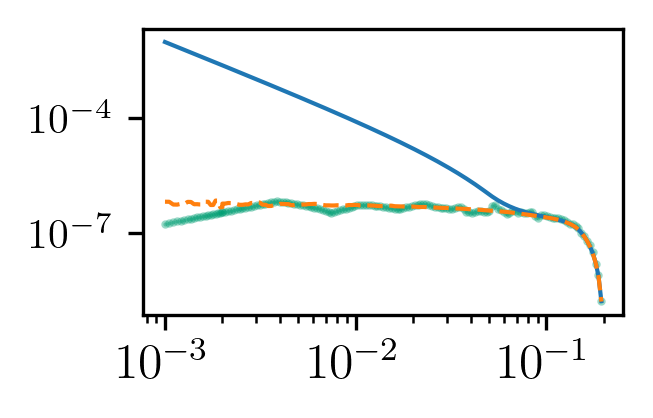

In [6]:
from qeep import qeresults as qres
QR = qres.QEResults(config, relative_path = ".")
get_norm_opt = QR.get_get_norm()
get_var_opt = QR.get_get_variance()

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

size = ic.size
factor = 1

N = get_norm_opt(key)
N = np.nan_to_num(N)
V = get_var_opt(key)

factor = 1/N**2
ax.scatter(Ks, N**2*pauto*factor, color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 1)
#ax.scatter(Ks, N**2*pauto_rescale*factor**4, color = COLORBLIND_PALETTE[3], alpha = 0.4, s = 1)
ax.loglog(Ks, N*factor, lw = 1)
ax.loglog(Ks, V*factor, lw = 1, ls = "--")
#ax.set_ylim(1e-7, 1e10)

## Apply to non-linear matter

In [7]:
simindex = 0
sim_name = f"{config['sim_params']['sim_name_base']}{simindex:03}"

direc = "/capstor/scratch/cscs/odarwish/ABACUS/"
delta_m = np.load(direc+f"delta_matter_{simindex}.npy")

In [8]:
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
ic = load_dens(ic_dir, sim_name, ngrid)*D_ratio
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size

delta_m_fft = rfftn(delta_m, overwrite_x=False, workers=nthread)
delta_m_fft /= delta_m.size

In [9]:
k, matter_auto = ru.calc_power_mu0_x_axis(delta_m_fft/f, box)
k, matter_cross = ru.calc_power_mu0_x_axis(delta_m_fft.astype(np.complex128)/f, box, delta_k2 = ic_fft.astype(np.complex128)/f)

In [10]:
configuration = '../configs/abacus/config_desi_asymm_no_shot.yaml'
configuration = '../configs/abacus/config_abacus_delta_m.yaml'
configuration = '../configs/abacus/config_desi_asymm_no_shot_kmax_10.yaml'
#configuration = '../configs/abacus/config_desi_symm_no_shot.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

biases = config['bias']
b1A = biases["b10_A"]
b1B = biases["b10_B"]

QR = qres.QEResults(config, relative_path = ".")
get_norm_opt = QR.get_get_norm()
get_var_opt = QR.get_get_variance()

In [11]:
pnlinf_A = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], b1A**2*gen_nl_power[:,1])
pnlinf_B = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], b1B**2*gen_nl_power[:,1])

ic_A = ic*b1A
ic_B = ic*b1B

delta_m_A, delta_m_B = b1A*delta_m, b1B*delta_m
key = "g"

In [12]:
W = ps.get_W_compensated(box, ngrid, paste, interlaced)

f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
    )

In [13]:
from qeep import biases

def get_cg_bias(key,biases_A, biases_B, e):
    if key == "g":
        return biases.cg_g(biases_A, biases_B, e)
    elif key == "s":
        return biases.cg_s(biases_A, biases_B, e)
    elif key == "t":
        return biases.cg_t(biases_A, biases_B, e)
    else:
        raise ValueError(f"Invalid key: {key}")

Nsize = ic.size

#ic_shift_AB = rec.get_rec(key, delta_m, box, kmin, kmax, pnlinf, plinf, real_field_2 = delta_m, Ptot_interp_2 = pnlinf)/Nsize**2
matter_rec = rec.get_rec(key, delta_m_A, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_m_B, Ptot_interp_2 = pnlinf_B)#/Nsize**2

ic_rec = rec.get_rec(key, ic_A, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = ic_B, Ptot_interp_2 = pnlinf_B)



In [14]:
k_bin_edges_default = np.linspace(1e-4, 0.2, 50)
#k_bin_edges_default = np.logspace(-3, -1, 20)


k, rec_cross = ru.calc_power_mu0_x_axis(matter_rec.astype(np.complex128), box, k_bin_edges = k_bin_edges_default, delta_k2 = ic_fft.astype(np.complex128))
#rec_cross = np.interp(Ks, k, rec_cross)

k, rec_auto = ru.calc_power_mu0_x_axis(matter_rec.astype(np.complex128), box, k_bin_edges = k_bin_edges_default)
#rec_auto = np.interp(Ks, k, rec_auto)

k, ic_auto = ru.calc_power_mu0_x_axis(ic_fft.astype(np.complex128), box, k_bin_edges = k_bin_edges_default)

k, rec_ic_auto = ru.calc_power_mu0_x_axis(ic_rec.astype(np.complex128), box, k_bin_edges = k_bin_edges_default)
#rec_ic_auto = np.interp(Ks, k, rec_ic_auto)

In [16]:
2*np.pi/(box**3)**(1/3), Ks.min(), k.min(), k.max()

(0.0031415926535897946, 0.001, 0.0031415926535897933, 0.19803450409575657)

In [17]:
N = get_norm_opt(key)
N = np.nan_to_num(N)
V = get_var_opt(key)

biases_A, biases_B = jnp.array([b1A, 0, 0]), jnp.array([b1B, 0, 0])

normalization = N
bias = 0
kinds = ["s", "t", "g"]
for kk in kinds:
    effective_bias = get_cg_bias(kk, biases_A, biases_B, 0)
    #biases.symm(biases.cg_t, biases_A, biases_B, e = 0)
    bias += (normalization*get_norm_opt(key, kk)**-1.)*effective_bias

normalization_interp = np.interp(k, Ks, normalization)

Plinear = np.interp(Ks, gen_power[:,0], gen_power[:,1])

In [18]:
#configuration_t = '../configs/abacus/config_abacus_kmax_01.yaml'

#with open(configuration_t, 'r') as f:
#    config_t = yaml.safe_load(f)
    
#i = 0
#direc = f"/users/odarwish/qeep/results/{config_t['name']}/"
#results = np.load(direc+f"results_analysis_{i}.npy", allow_pickle = True).item()

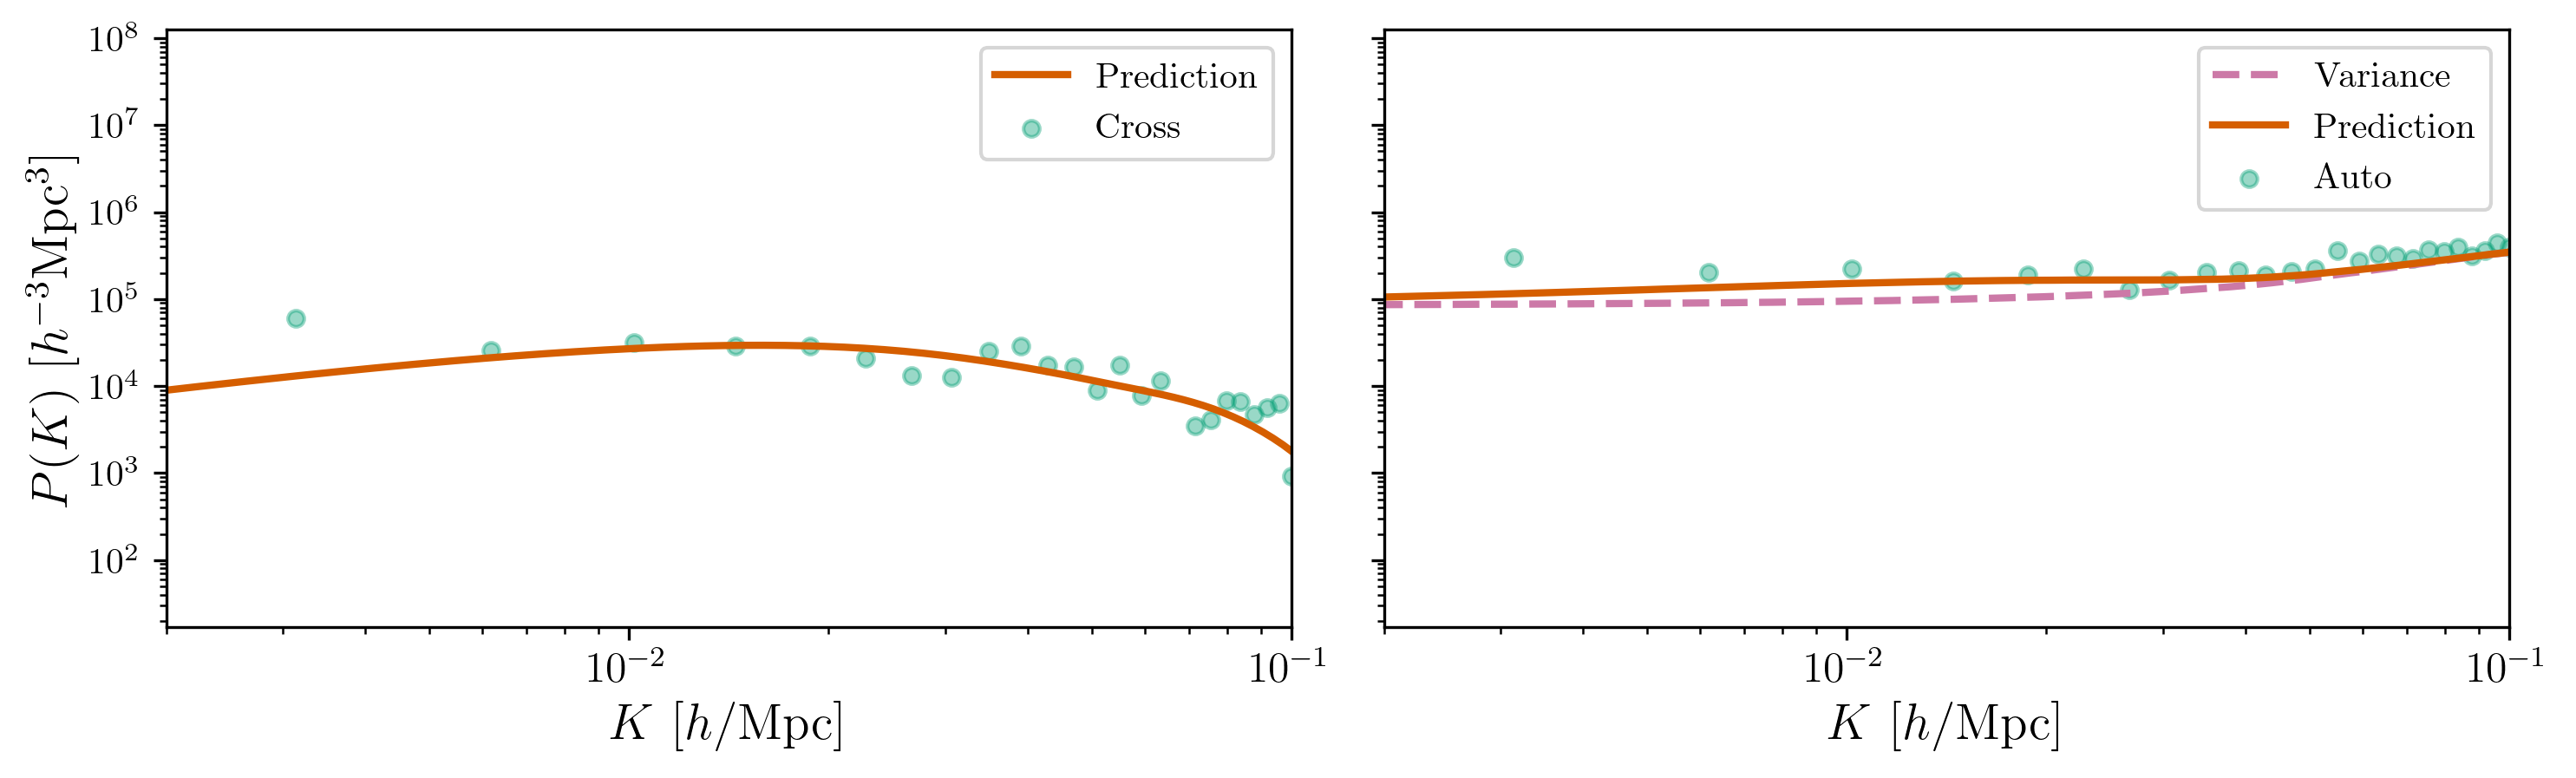

In [19]:
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 10  # inches
FIG_HEIGHT = FIG_WIDTH//2 * GOLDEN_RATIO
DPI = 300

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 2, figure=fig)

ax_left = fig.add_subplot(gs[0, 0])

Plinear = np.interp(Ks, gen_power[:,0], gen_power[:,1])

cross_signal_prediction = Plinear*bias
auto_signal_prediction = Plinear*bias**2+V
auto_signal_matter_prediction = Plinear

cross_error_2 = (cross_signal_prediction**2+auto_signal_prediction*auto_signal_matter_prediction)
cross_error_2 = np.interp(k, Ks, cross_error_2)
deltak = k[1]-k[0]
Nmodes = 4*np.pi*k**2*deltak/(2*np.pi/box)**3
#cross_error_2 /= Nmodes
cross_error = np.sqrt(cross_error_2)

ax_left.loglog(Ks, cross_signal_prediction, label = "Prediction", color = COLORBLIND_PALETTE[1], lw = 2)
ax_left.scatter(k, rec_cross*normalization_interp, label = "Cross", color = COLORBLIND_PALETTE[2], alpha= 0.4, s = 20)
#ax_left.errorbar(k, rec_cross*normalization_interp, cross_error)

ax_left.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=14)
ax_left.set_ylabel(r'$P(K) \ [h^{-3}\mathrm{Mpc^{3}]}$', fontsize=14)
ax_left.legend(fontsize = 10)

ax_left.set_xlim(2e-3, 0.1)
ax.set_ylim(10)

"""
ax_left.set_xlim(2e-3, 0.1)
ax.set_ylim(ymin = 10)
plt.show()

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
gs = GridSpec(1, 1, figure=fig)
"""

ax = fig.add_subplot(gs[1], sharey=ax_left)
plt.setp(ax.get_yticklabels(), visible=False)

ax.loglog(Ks, V, label = "Variance", color = COLORBLIND_PALETTE[3], lw = 2, ls = "--")
#ax.scatter(k, rec_ic_auto*normalization_interp**2, label = "IC rec auto", color = COLORBLIND_PALETTE[3], alpha = 0.5, s = 5)

ax.loglog(Ks, auto_signal_prediction, label = "Prediction", color = COLORBLIND_PALETTE[1], lw = 2)

ax.scatter(k, rec_auto*normalization_interp**2, label = "Auto", color = COLORBLIND_PALETTE[2], alpha= 0.4, s = 20)


ax.set_xlim(2e-3, 0.1)
#ax.set_ylim(1e-1, 1e6)

ax.legend(fontsize = 10)
ax.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=14)

fig.savefig(f"/users/odarwish/long-modes/figures/matter_biased_by_hand_sims.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()

plt.show()

(0.005, 0.1)

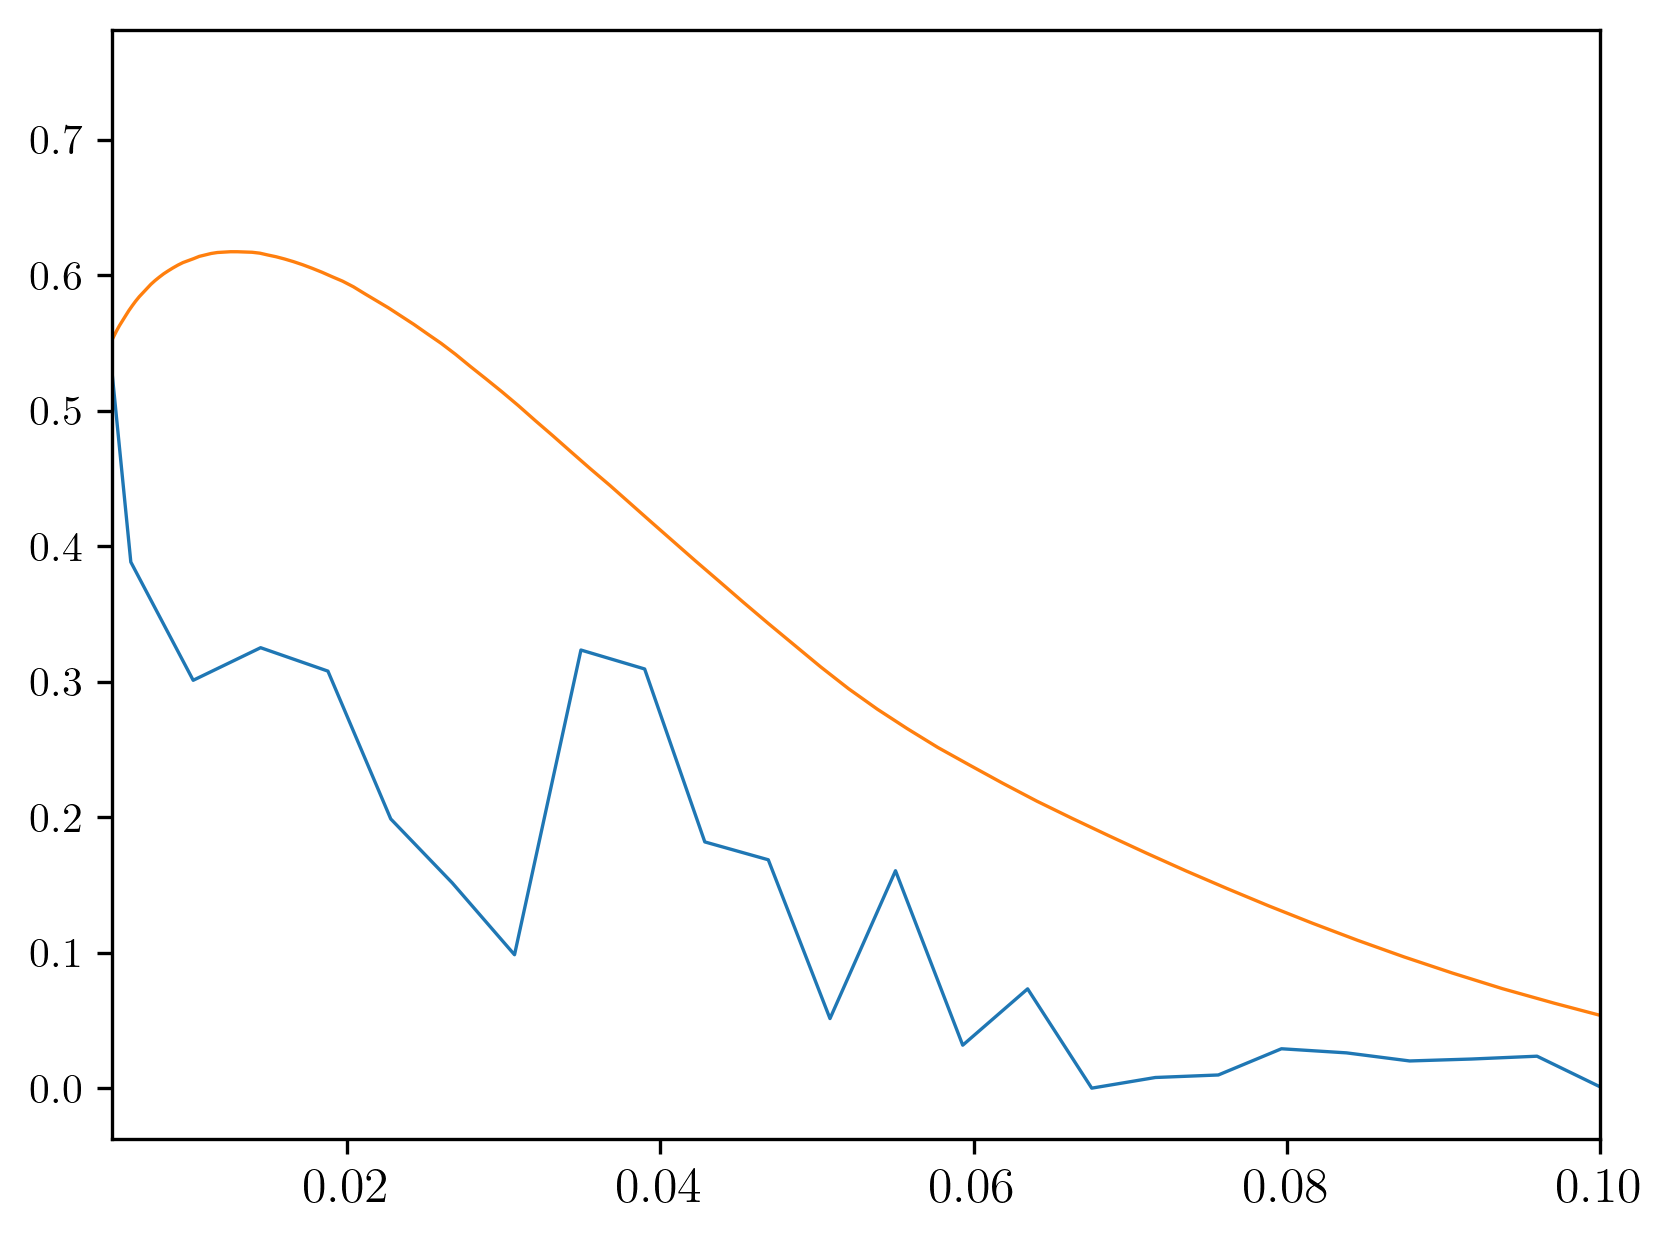

In [20]:
r2 = rec_cross**2/(rec_auto*ic_auto)
r = np.sqrt(r2)
plt.plot(k, r2)

cross_signal_prediction = Plinear*bias
auto_signal_prediction = Plinear*bias**2+V

plt.plot(Ks, np.sqrt(cross_signal_prediction**2/(auto_signal_prediction*Plinear)))

plt.xlim(0.005, 0.1)

## Galaxies mixed

In [22]:
from nbodykit.source.mesh.field import FieldMesh
import nbodykit.lab as nblab
from pmesh.pm import RealField, ComplexField
from nbodykit.algorithms.fftpower import FFTPower


In [23]:
def quick_nbody_power(input_field_fft, second_fft = None):
    delta_mesh = nblab.ArrayMesh(irfftn(input_field_fft), BoxSize=box)
    second = nblab.ArrayMesh(irfftn(second_fft), BoxSize=box) if second_fft is not None else None
    r = FFTPower(delta_mesh, mode='1d', second = second)
    Pk = r.power
    kn = Pk['k']
    powergn_alt = Pk['power'].real
    kn = Pk['k']
    powergn_alt = Pk['power'].real
    return kn, powergn_alt*size**2

In [24]:
simulations_results = {}

In [195]:
configuration = '../configs/abacus/config_abacus_recs.yaml'
configuration = '../configs/abacus/config_abacus_recs_kmax_10.yaml'
configuration = '../configs/abacus/config_abacus_recs_kmax_20_new_shot.yaml'

simindex = 1

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

filename_prefix = f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_LRG_LRG"
filename_prefix = f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_LRG_ELG"

QR = qres.QEResults(config, relative_path = ".", filename_prefix = filename_prefix)
get_norm_opt = QR.get_get_norm()
get_var_opt = QR.get_get_variance()
get_bisp_opt = QR.get_get_bispectrum_mixed()
get_trisp_opt = QR.get_get_trispectrum()

In [196]:
simulations_results[simindex] = {}

In [202]:

#let's get some quantities from the abacus utils
from abacusnbody.metadata import get_meta
from abacusnbody.hod.zcv.ic_fields import load_dens, load_disp

sim_name = f"{config['sim_params']['sim_name_base']}{simindex:03}"
z = config['sim_params']['z_mock']

meta = get_meta(sim_name, redshift=z)

z_ic = meta['InitialRedshift']

Dz = meta['GrowthTable']
ztarget = 0.5
zpk = meta['ZD_Pk_file_redshift']  # 1.0
pk = meta['CLASS_power_spectrum']
linear_k  = pk['k (h/Mpc)']
input_pk = pk['P (Mpc/h)^3']
linear_pk = input_pk * (Dz[ztarget] / Dz[zpk])**2

D_ratio = meta['GrowthTable'][meta['Redshift']] / meta['GrowthTable'][z_ic] #re-scaling growth factor between initial redshift and current redshift

#here we specify the inital conditions, useful to get the linear density field
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
ic = load_dens(ic_dir, sim_name, ngrid)*D_ratio
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size

from jax import numpy as jnp
from qeep import rec, rec_utils as ru, qeutils as qu

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax'] #kmin, kmax of reconstruction

#here we are loading some simulation results
#we used the ZCV utils from abacusutils to get this info
z_mock = 0.5
scratch = f"/users/odarwish/scratch/ABACUS/abacus_out/{sim_name}/z{z_mock:.3f}/galaxies/"

samples = ["LRG", "ELG"]
#samples = ["LRG", "LRG"]

key = "s"
trA, trB = samples

out_info_A = np.load(scratch+f"{samples[0]}_out_info.npy", allow_pickle=True).item()
out_info_B = np.load(scratch+f"{samples[1]}_out_info.npy", allow_pickle=True).item()

kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks])
Ks = np.unique(Ks)

W = ps.get_W_compensated(box, ngrid, paste, interlaced)

f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
    )

scratch = f"/users/odarwish/scratch/ABACUS/abacus_out/AbacusSummit_base_c000_ph{simindex:03}/z0.500/galaxies/"
delta_LRG = np.load(scratch+f"{samples[0]}_delta_g.npy")
#delta_LRG = ic*out_info_A['b1']
#delta_ELG = delta_LRG
delta_ELG = np.load(scratch+f"{samples[1]}_delta_g.npy") if trA != trB else delta_LRG

kA = out_info_A["k"]
kB = out_info_B["k"]

PAA = out_info_A["Ptot"]
PBB = out_info_B["Ptot"]

pnlinf_A = lambda kmag: jnp.interp(kmag, kA, PAA)
pnlinf_B = lambda kmag: jnp.interp(kmag, kB, PBB)

#ic_shift_AB = rec.get_shift_n_rec(delta_LRG, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_ELG, Ptot_interp_2 = pnlinf_B)

ic_shift_AB = rec.get_rec(key, delta_LRG, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_ELG, Ptot_interp_2 = pnlinf_B)


/users/odarwish/qeep/qeep/rec.py:178: RuntimeWarning: divide by zero encountered in divide
  inv_kmag_2 = 1/kmag**2


In [203]:
delta_LRG_fft = rfftn(delta_LRG, overwrite_x=False, workers=nthread)
delta_LRG_fft /= delta_LRG.size

In [204]:

k_bin_edges_default = np.linspace(1e-4, 0.2, 50)

k, p = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box, delta_k2 = ic_fft.astype(complex), k_bin_edges = k_bin_edges_default)
#p = np.interp(Ks, k, p)

k, p_lrg = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box, delta_k2 = delta_LRG_fft.astype(complex), k_bin_edges = k_bin_edges_default)

k, pauto_ic = ru.calc_power_mu0_x_axis(ic_fft.astype(complex), box, k_bin_edges = k_bin_edges_default)


k, pauto = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box, k_bin_edges = k_bin_edges_default)
#pauto = np.interp(Ks, k, pauto)

#k_nb, pcross_nb = quick_nbody_power(ic_shift_AB, second_fft = ic_fft)
#pcross_nb = np.interp(Ks, k_nb, pcross_nb)
#k_nb, pauto_nb = quick_nbody_power(ic_shift_AB)
#pauto_nb = np.interp(Ks, k_nb, pauto_nb)

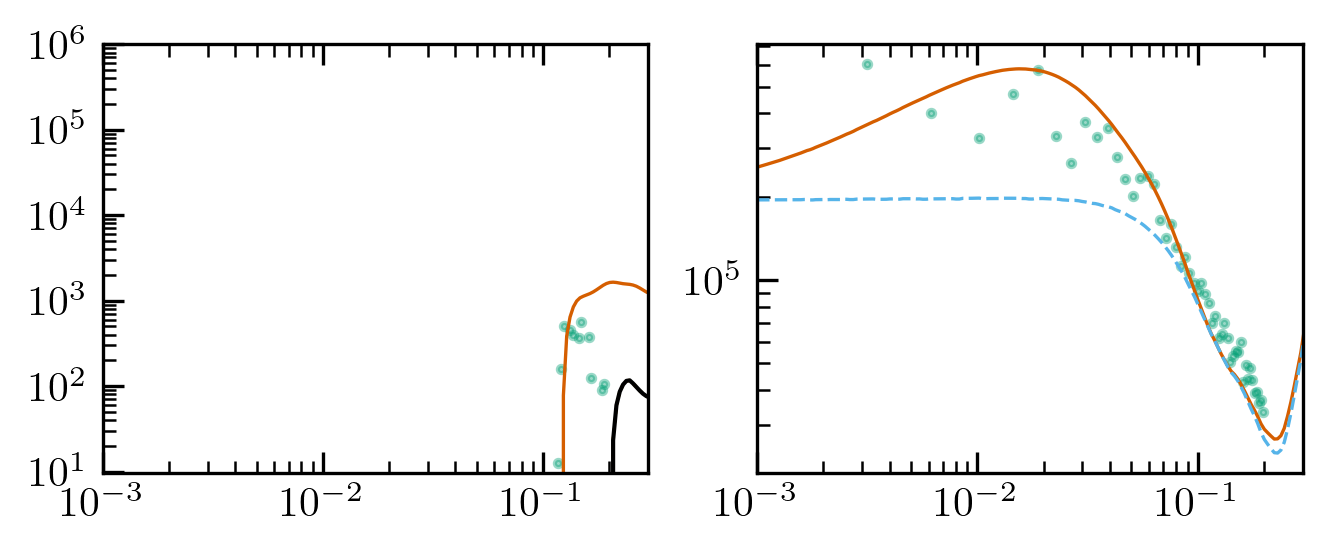

In [207]:
results_sim = {}

Fg_factor = 21/17

g = lambda b1_A, b2_A, b1_B, b2_B: b1_A*b1_B+1/2*21/17*(b1_A*b2_B+b1_B*b2_A) 
s = lambda b1_A, b1_B: b1_A*b1_B
t = lambda b1_A, bs2_A, b1_B, bs2_B:  b1_A*b1_B+1/2*7/2*(b1_A*bs2_B+b1_B*bs2_A) 

a1, a2 = 1, -17/21
b_2_eul =  lambda info: 2*(a1 + a2)*(info["b1"]-1)+a2*info["b2_L"]/4

biases_rec = {"g": g(out_info_A["b1"], out_info_A["b2"]/2, out_info_B["b1"], out_info_B["b2"]/2), "s": s(out_info_A["b1"], out_info_B["b1"]), "t": t(out_info_A["b1"], out_info_A["bs"], out_info_B["b1"], out_info_B["bs"])}
#biases_rec = {"g": g(out_info_A["b1"], b_2_eul(out_info_A), out_info_B["b1"], b_2_eul(out_info_B)), "s": s(out_info_A["b1"], out_info_B["b1"]), "t": t(out_info_A["b1"], out_info_A["bs"], out_info_B["b1"], out_info_B["bs"])}

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects
import matplotlib as mpl


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm"  # Use Computer Modern math font
})


COLORBLIND_PALETTE = [
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#56B4E9',  # Light blue
    '#E69F00',  # Yellow
    '#000000',  # Black
    '#F0E442'   # Light yellow
]

# Use golden ratio for figure dimensions
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 5  # inches
FIG_HEIGHT = 3 * GOLDEN_RATIO
DPI = 300

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 2, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
                   top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

size = ic.size
factor = 1

normalization = get_norm_opt(key)
variance = get_var_opt(key)

normalization_interp = np.interp(k, Ks, normalization)

bias = 0
unbiased_bias = 0
kinds = ["s", "t", "g"]
for kk in kinds:
    temp = (normalization*get_norm_opt(key, kk)**-1.)
    bias += temp*biases_rec[kk]
    unbiased_bias += temp
    #plt.plot(Ks, temp, label = kk)

cross_sim = p*normalization_interp
ax.scatter(k, (cross_sim), color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 3)
#ax.scatter(k, (p_lrg*normalization_interp), color = COLORBLIND_PALETTE[6], alpha = 0.4, s = 3)
#ax.scatter(Ks, (pcross_nb*normalization), color = COLORBLIND_PALETTE[5], alpha = 0.4, s = 1)

results_sim["cross_sim"] = (Ks, cross_sim)
#results_sim["cross_sim_nb"] = (Ks, pcross_nb*normalization)

bias = 0
no_rec_bias = 0
kinds = ["s", "t", "g"]
for kk in kinds:
    temp = (normalization*get_norm_opt(key, kk)**-1.)
    bias += temp*biases_rec[kk]
    no_rec_bias += temp

shot_noise = 0#get_bisp_opt(key)
prediction_cross = bias*plinf(Ks)#+shot_noise
prediction_cross_nl = bias*pnlinf(Ks)
results_sim["cross_theory"] = (Ks, prediction_cross)
ax.loglog(Ks, (prediction_cross), color = COLORBLIND_PALETTE[1])
ax.loglog(Ks, (no_rec_bias*plinf(Ks)), color = COLORBLIND_PALETTE[5], ls = ":")
ax.loglog(Ks, (no_rec_bias*plinf(Ks)+shot_noise), color = COLORBLIND_PALETTE[6], lw = 1)

#ax.loglog(Ks, bias*plinf(Ks), color = COLORBLIND_PALETTE[3])
ax.set_xlim(1e-3, 0.3)
ax.set_ylim(ymax = 1e6)


ax = fig.add_subplot(gs[0, 1])
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
                   top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

shot_noise = 0#get_trisp_opt(key)
variance = get_var_opt(key)

prediction_auto = bias**2*plinf(Ks)+variance+shot_noise
prediction_auto_signal = bias**2*plinf(Ks)

#ax.plot(Ks, shot_noise)

auto_sim = pauto*normalization_interp**2#*factor**4
ax.scatter(k, auto_sim, color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 3)
results_sim["auto_sim"] = (Ks, auto_sim)
#results_sim["auto_sim_nb"] = (Ks, pauto_nb*normalization**2)

ax.loglog(Ks, prediction_auto, color = COLORBLIND_PALETTE[1])
ax.loglog(Ks, variance, color = COLORBLIND_PALETTE[4], ls = "--")
#ax.loglog(Ks, prediction_auto_signal, color = COLORBLIND_PALETTE[2], lw = 1)
results_sim["auto_theory"] = (Ks, prediction_auto)
#ax.loglog(Ks, no_rec_bias**2*plinf(Ks)+N+shot_noise, color = COLORBLIND_PALETTE[5], ls = ":")
#ax.loglog(Ks, variance+shot_noise, color = COLORBLIND_PALETTE[2], ls = "--")
#ax.loglog(Ks, variance, color = COLORBLIND_PALETTE[3], ls = "--")
ax.set_xlim(1e-3, 0.3)
#ax.set_ylim(ymax = 1e6)

simulations_results[simindex][key] = results_sim


In [208]:
simulations_results[1].keys()

dict_keys(['g', 's'])

In [263]:
from scipy.optimize import curve_fit

indexsim = 1

data_g = simulations_results[indexsim]["g"]["cross_sim"][1]
data_s = simulations_results[indexsim]["s"]["cross_sim"][1]
selection = k<0.1
k_sel = k[selection]
data_g_sel = data_g[selection]
data_s_sel = data_s[selection]

kinds = ["s", "t", "g"]

def get_bias(key, kinds):
    normalization = get_norm_opt(key)
    def biasf(x, Cs, Ct, Cg):
        lista = [Cs, Ct, Cg]
        result = np.sum([lista[i]*(normalization*get_norm_opt(key, kk)**-1.) for i, kk in enumerate(kinds)], axis = 0)
        return np.interp(x, Ks, result)
    return biasf

def get_power(key, kinds, PL):
    normalization = get_norm_opt(key)
    def power(x, Cs, Ct, Cg):
        lista = [Cs, Ct, Cg]
        result = np.sum([lista[i]*(normalization*get_norm_opt(key, kk)**-1.) for i, kk in enumerate(kinds)], axis = 0)
        return np.interp(x, Ks, result)*PL
    return power

b1A, b1B = out_info_A["b1"], out_info_B["b1"]

def get_power_fixed_Cs(key, kinds, PL):
    normalization = get_norm_opt(key)
    def power(x, Cg):
        Cs = b1A*b1B
        Ct = biases_rec["t"]
        lista = [Cs, Ct, Cg]
        result = np.sum([lista[i]*(normalization*get_norm_opt(key, kk)**-1.) for i, kk in enumerate(kinds)], axis = 0)
        return np.interp(x, Ks, result)*PL
    return power


PL = plinf(k_sel)

popt_g, pcov_g = curve_fit(get_power_fixed_Cs("g", kinds, PL), k_sel, data_g_sel)
popt_s, pcov_s = curve_fit(get_power_fixed_Cs("s", kinds, PL), k_sel, data_s_sel)

In [264]:
popt_g, popt_s, biases_rec["g"]

(array([1.85350187]), array([0.8166435]), 1.2943510446242905)

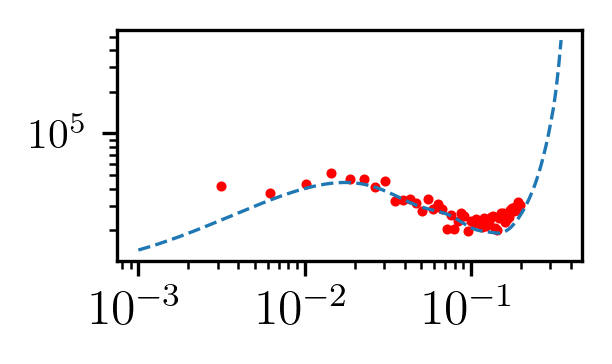

In [269]:
plt.figure(figsize=(2, 1))
k_sel = "g"

Clist = [b1A*b1B, biases_rec["t"], popt_g[0]]
#Clist = [b1A*b1B, biases_rec["t"], biases_rec["g"]]
bias_new = get_bias(k_sel, kinds)(Ks, *Clist)

#plt.loglog(Ks, prediction_auto, color = COLORBLIND_PALETTE[1])
plt.loglog(Ks, bias_new**2*plinf(Ks)+get_var_opt(k_sel), ls = "--")
plt.scatter(k, simulations_results[indexsim][k_sel]["auto_sim"][1], color = "red", s = 2)

In [162]:
popt_s, popt_g, b1A*b1B, biases_rec

(array([10.66440788,  3.04388674]),
 array([22.10407085,  2.08176938]),
 2.1845768662063665,
 {'g': 1.1554261505030823, 's': 2.1845768662063665, 't': -5.178182663680074})

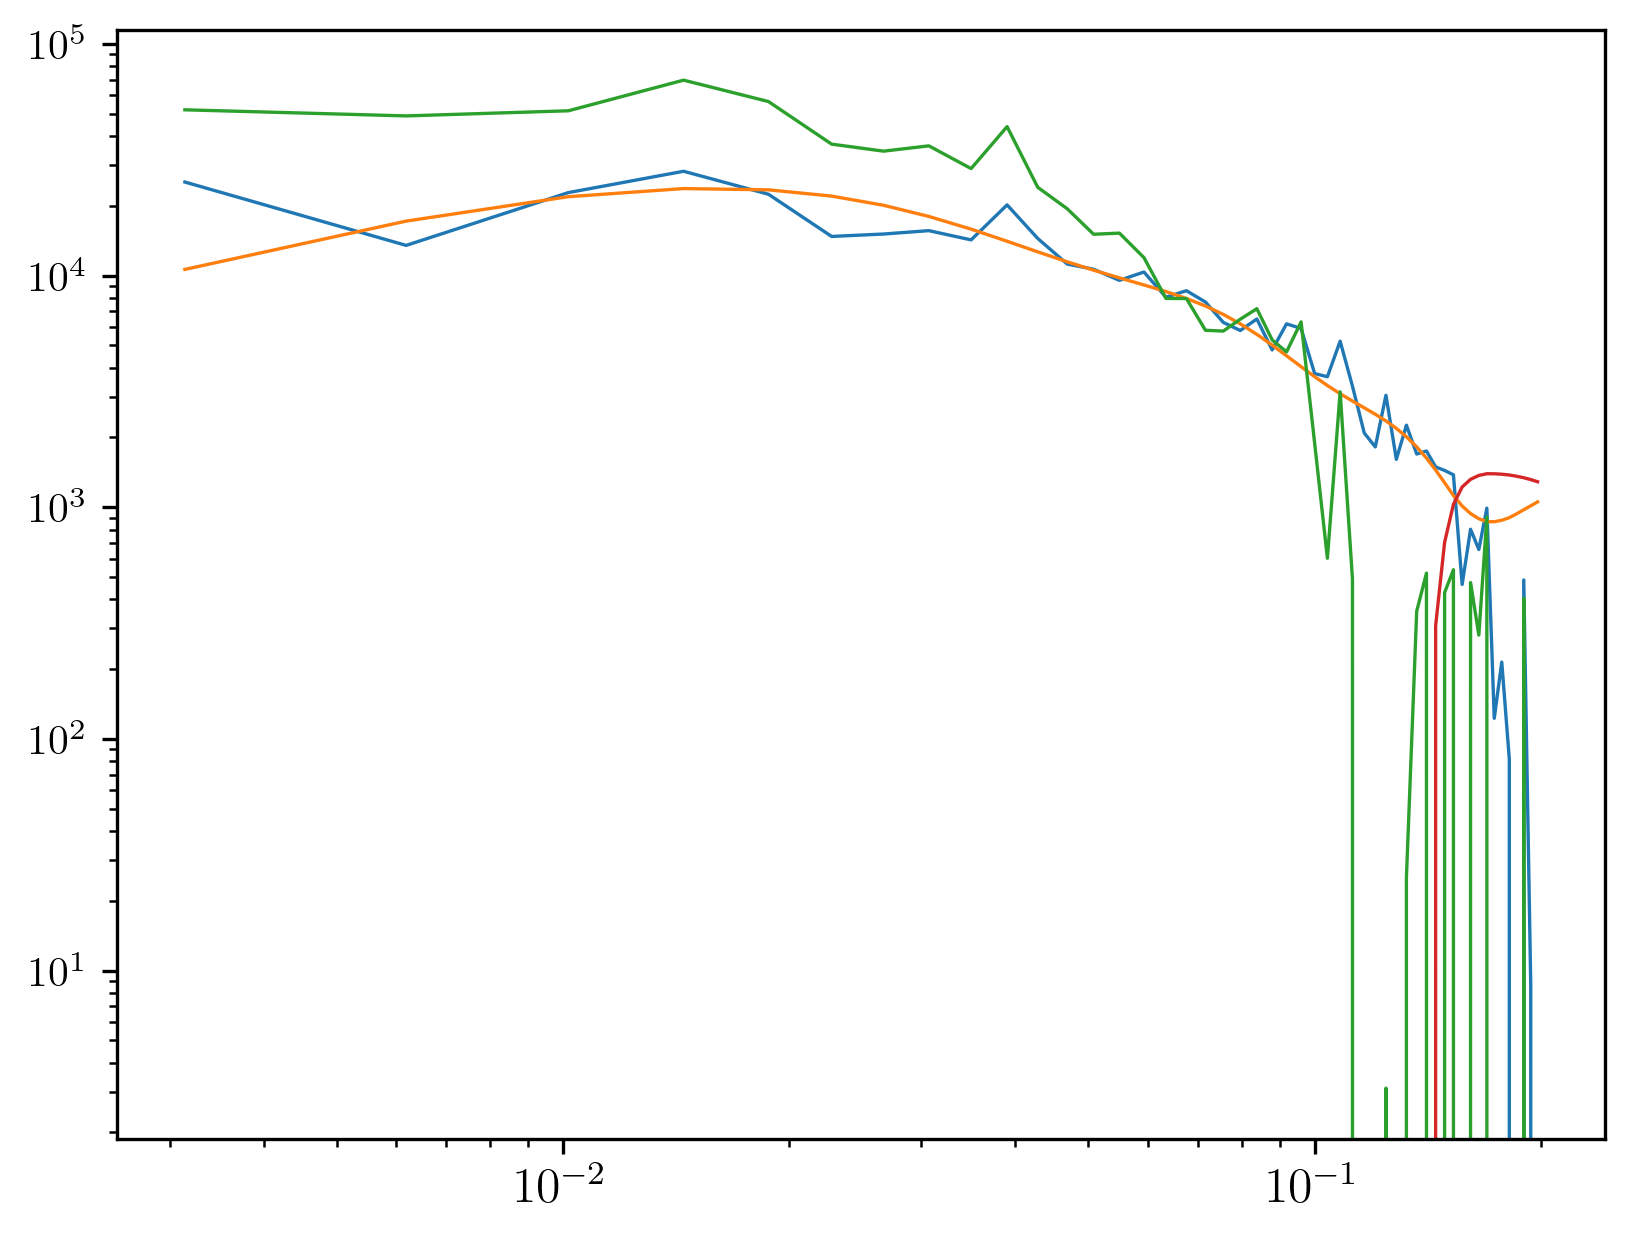

In [166]:
PL = plinf(k)

plt.loglog(k, data_g)
plt.loglog(k, get_power_fixed_Cs("g", kinds, PL)(k, *popt_g))

plt.loglog(k, -data_s)
plt.loglog(k, -get_power_fixed_Cs("s", kinds, PL)(k, *popt_g))

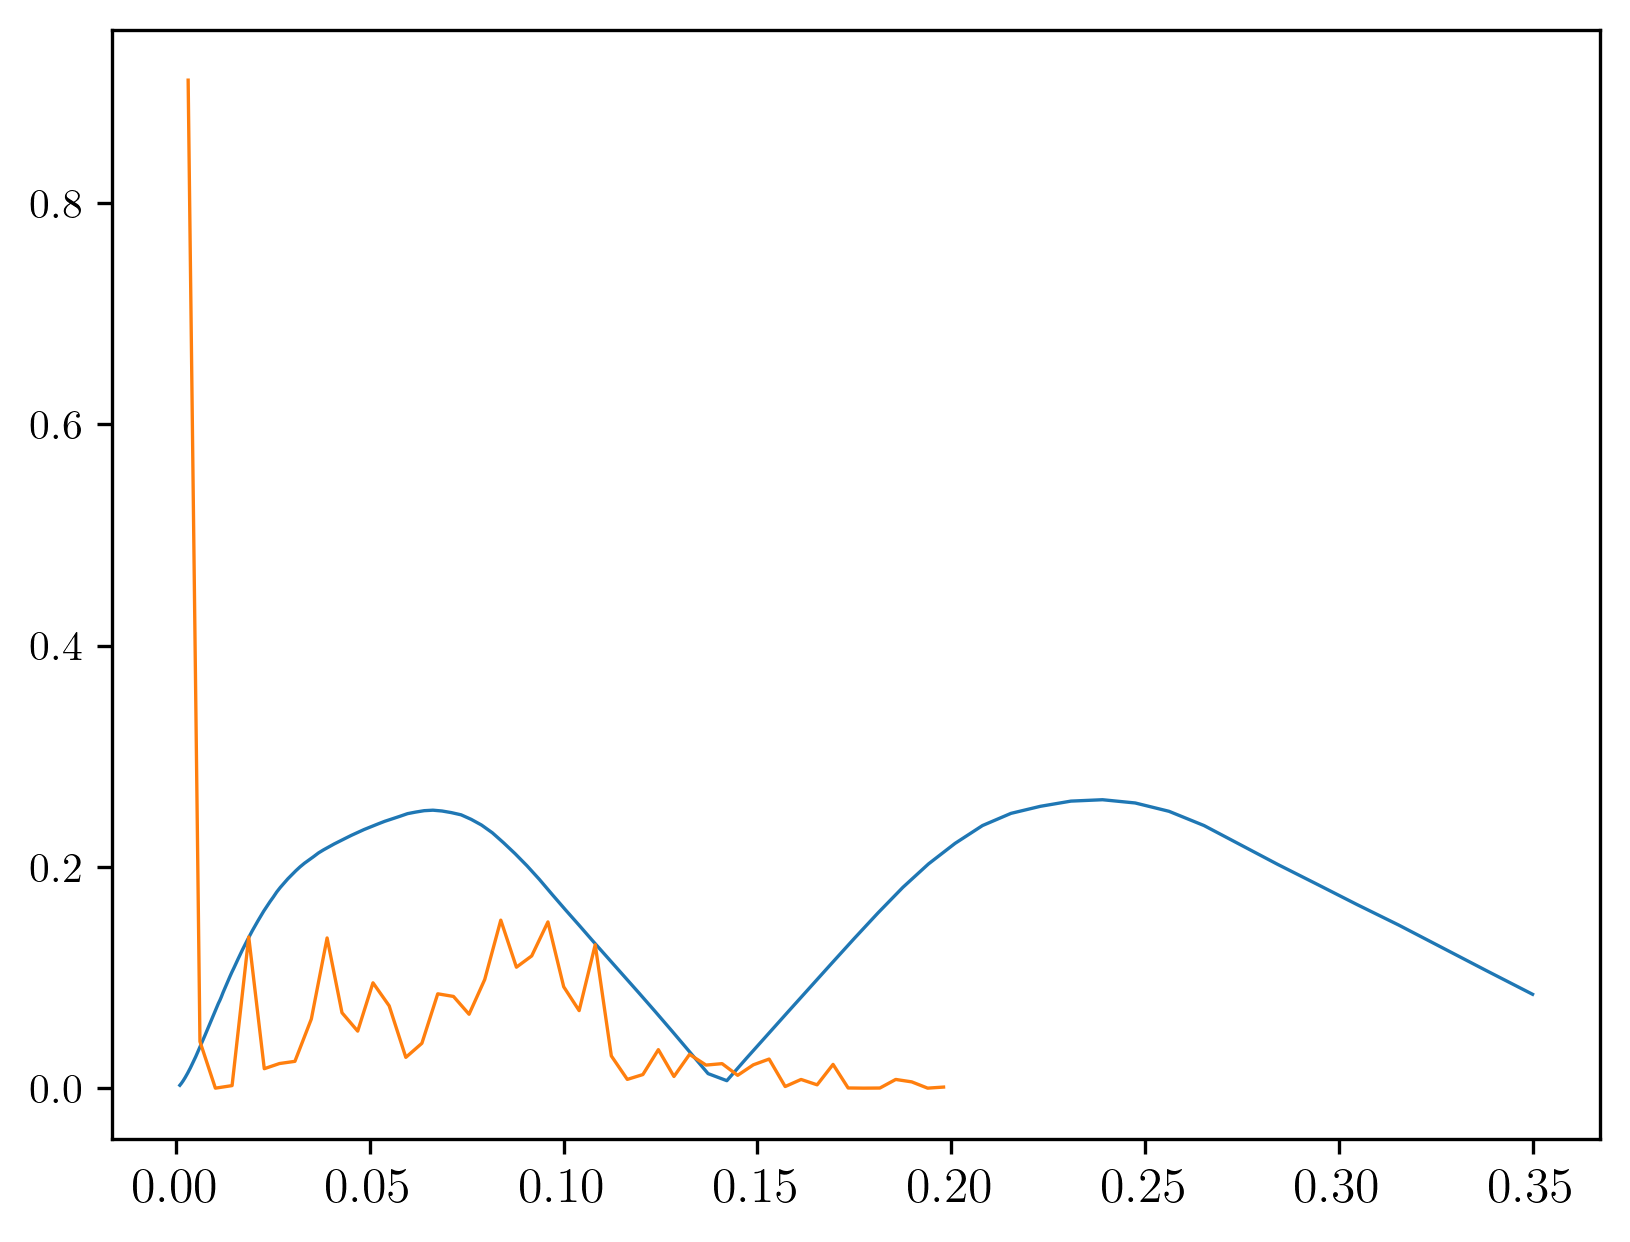

In [60]:
prediction_cross = bias*plinf(Ks)
prediction_auto = bias**2*plinf(Ks)+variance
r2theory = prediction_cross**2/(prediction_auto*plinf(Ks))
rtheory = np.sqrt(r2theory)
plt.plot(Ks, rtheory)

r2 = p**2/(pauto*pauto_ic)
r = np.sqrt(r2)
plt.plot(k, r2)

In [61]:
(simulations_results.keys())

dict_keys([2, 3, 0])

### Take mean

In [28]:
Nsims = len(simulations_results.keys())
lista = list(range(0, Nsims))
lista = [1]
Nsims = len(lista)
print("Nsims", Nsims)
auto_mean = 0
auto_mean_sim = 0
cross_mean = 0

casi = ["auto", "cross"]
final_results = {}
final_results_nb = {}

for caso in casi:

    auto_sims = []
    auto_means = []
    auto_sims_nb = []
    
    for index in lista:
        results = simulations_results[index][key]
        
        Ks, auto_sim = results[f"{caso}_sim"]
        auto_sims.append(auto_sim)
        
        #Ks, auto_sim = results[f"{caso}_sim_nb"]
        #auto_sims_nb.append(auto_sim)
        
        Ks, auto = results[f"{caso}_theory"]
        auto_means.append(auto)
        
        #plt.loglog(auto_sim)

    #plt.show()

    
    auto_sims = np.array(auto_sims)
    auto_sims_nb = np.array(auto_sims_nb)
    auto_means = np.array(auto_means)
    
    final_results[caso] = (auto_sims.mean(axis = 0), auto_sims.std(axis = 0), auto_means.mean(axis = 0), auto_means.std(axis = 0))
    final_results_nb[caso] = (auto_sims_nb.mean(axis = 0), auto_sims_nb.std(axis = 0), auto_means.mean(axis = 0), auto_means.std(axis = 0))

#plt.loglog(Ks, auto_mean_sim, lw = 2)
#plt.loglog(Ks, auto_mean, lw = 1, ls = "--")
#plt.xlim(1e-3, 1e-1)

Nsims 1


/tmp/ipykernel_146910/2276072800.py:42: RuntimeWarning: Mean of empty slice.
  final_results_nb[caso] = (auto_sims_nb.mean(axis = 0), auto_sims_nb.std(axis = 0), auto_means.mean(axis = 0), auto_means.std(axis = 0))
/users/odarwish/lenscarf/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/users/odarwish/lenscarf/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/users/odarwish/lenscarf/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/users/odarwish/lenscarf/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(0.001, 0.1)

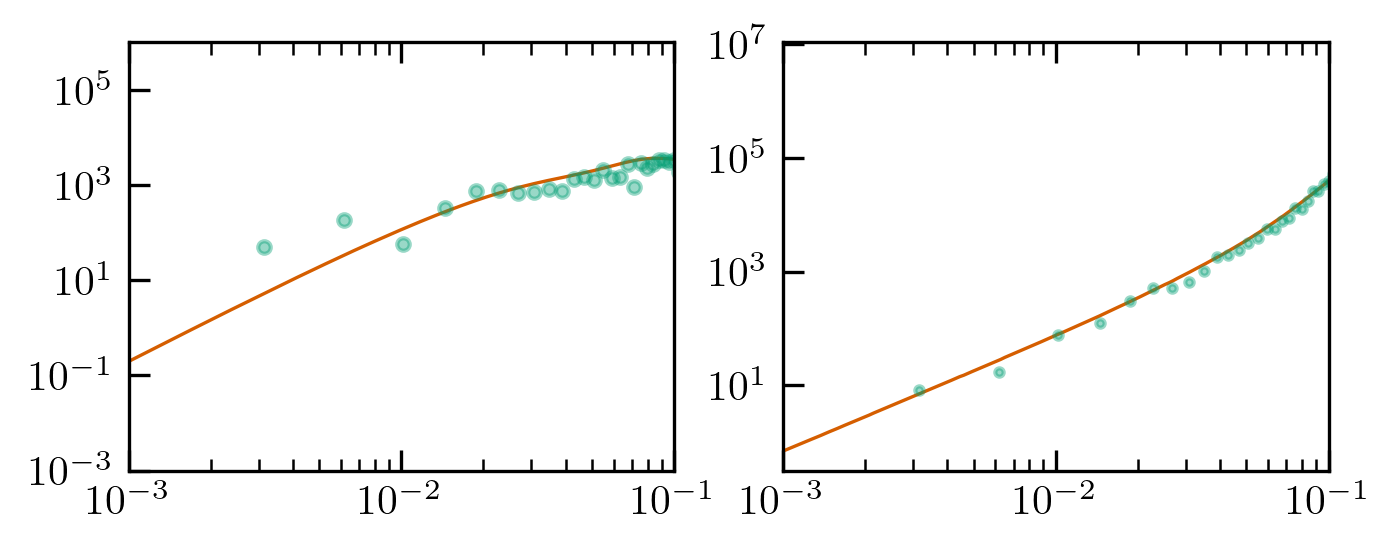

In [29]:
fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 2, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
                   top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

#even index mean, odd index std

#ax.scatter(Ks, final_results["cross"][0], color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 3)

ax.errorbar(k, final_results["cross"][0], yerr=final_results["cross"][1], 
           fmt='o',  # Circle markers
           #capsize = 1,  # Cap size for error bars
           #capthick = 2,  # Cap thickness
           #elinewidth = 1,  # Error bar line width
           markersize = 3,  # Marker size
           color= COLORBLIND_PALETTE[2],
           alpha= 0.4)

ax.loglog(Ks, final_results["cross"][2], color = COLORBLIND_PALETTE[1])
#ax.loglog(Ks, (no_rec_bias*plinf(Ks)), color = COLORBLIND_PALETTE[5], ls = ":")
#ax.loglog(Ks, (no_rec_bias*plinf(Ks)+shot_noise), color = COLORBLIND_PALETTE[6], lw = 1)

ax.set_xlim(1e-3, 0.1)
ax.set_ylim(ymin = 1e-3, ymax = 1e6)

ax = fig.add_subplot(gs[0, 1])
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
                   top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

#ax.scatter(Ks, final_results_nb["auto"][0], color = COLORBLIND_PALETTE[2], alpha = 0.4, s = 3)
#ax.scatter(Ks, final_results["auto"][0], color = COLORBLIND_PALETTE[3], alpha = 0.4, s = 3)

ax.errorbar(k, final_results["auto"][0], yerr=final_results["auto"][1], 
           fmt='o',  # Circle markers
           #capsize = 1,  # Cap size for error bars
           #capthick = 2,  # Cap thickness
           #elinewidth = 1,  # Error bar line width
           markersize = 2,  # Marker size
           color= COLORBLIND_PALETTE[2],
           alpha= 0.4)

ax.loglog(Ks, final_results["auto"][2], color = COLORBLIND_PALETTE[1])
#ax.loglog(Ks, prediction_auto_signal, color = COLORBLIND_PALETTE[2], lw = 1)
ax.set_xlim(1e-3, 0.1)

In [57]:
configuration_new_shot = '../configs/abacus/config_abacus_recs_kmax_10_new_shot.yaml'
configuration_new_shot = '../configs/abacus/config_abacus_recs_kmax_20_new_shot.yaml'

simindex = 1
with open(configuration_new_shot, 'r') as f:
    config_new_shot = yaml.safe_load(f)
filename_prefix = f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_LRG_ELG"
QR_new = qres.QEResults(config_new_shot, relative_path = ".", filename_prefix = filename_prefix)
get_norm_opt_new = QR_new.get_get_norm()
get_var_opt_new = QR_new.get_get_variance()
get_bisp_opt_new = QR_new.get_get_bispectrum_mixed()
get_trisp_opt_new = QR_new.get_get_trispectrum()

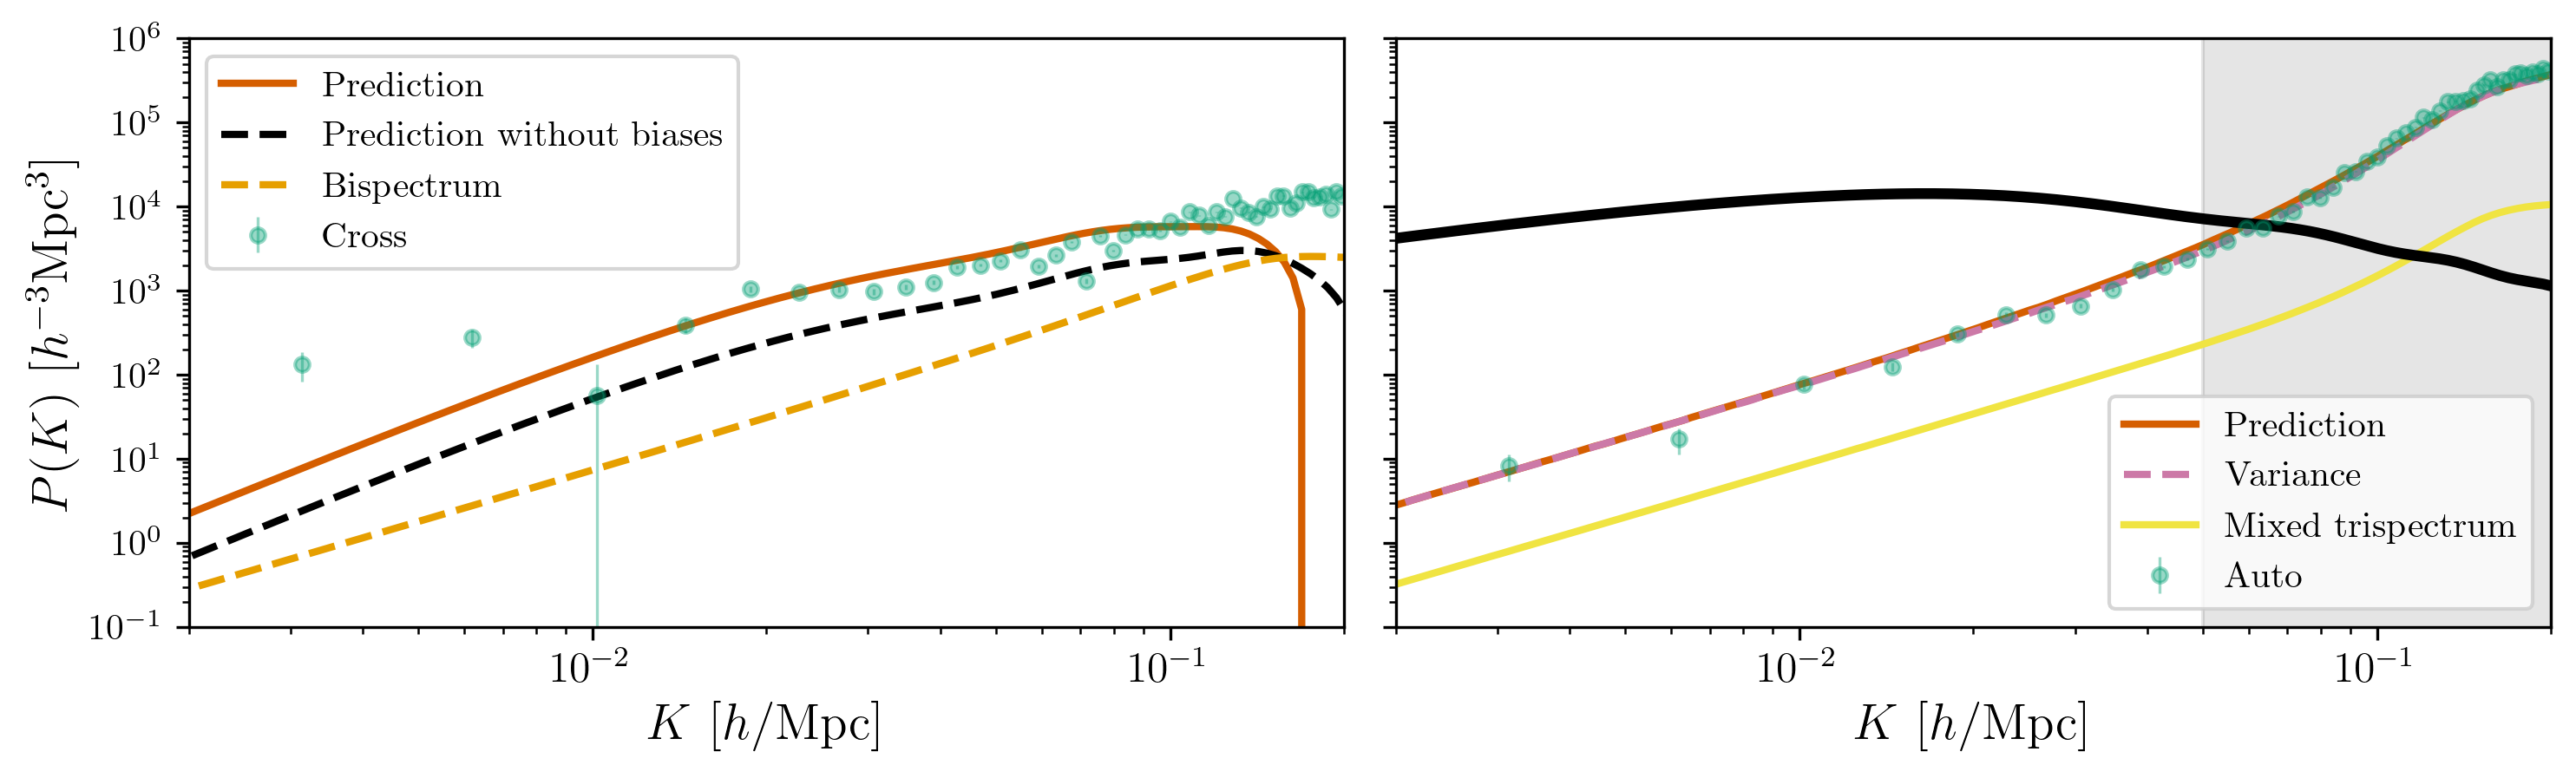

In [58]:
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 10  # inches
FIG_HEIGHT = FIG_WIDTH//2 * GOLDEN_RATIO
DPI = 300

normalization = get_norm_opt(key)
variance = get_var_opt(key)

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 2, figure=fig)

ax_left = fig.add_subplot(gs[0, 0])

bis = get_bisp_opt_new(key)
variance = get_var_opt(key)
tri = get_trisp_opt(key)

total_prediction = out_info_A["b1"]*final_results["auto"][2]+tri
total_prediction = np.interp(k, Ks, total_prediction)
deltak = k[1]-k[0]
V = box**3
err2 = (2*np.pi**2)/V/k**2/deltak*total_prediction**2
err_auto = np.sqrt(err2)

cross_prediction = final_results["cross"][2]
cross_prediction = np.interp(k, Ks, cross_prediction)
cross_variance = cross_prediction**2+total_prediction*plinf(k)
err2 = (2*np.pi**2)/V/k**2/deltak/2*cross_variance
err_cross = np.sqrt(err2)

#ax_left.scatter(k, (p_lrg*normalization_interp), color = COLORBLIND_PALETTE[6], alpha = 0.4, s = 10)
#final_results["cross"][0]
ax_left.errorbar(k, (p_lrg*normalization_interp), yerr = err_cross, #yerr=final_results["cross"][1], 
           fmt='o',  # Circle markers
           #capsize = 1,  # Cap size for error bars
           #capthick = 2,  # Cap thickness
           #elinewidth = 1,  # Error bar line width
           markersize = 4,  # Marker size
           color= COLORBLIND_PALETTE[2],
           alpha= 0.4, label = "Cross")

ax_left.loglog(Ks, out_info_A["b1"]*final_results["cross"][2]+bis, color = COLORBLIND_PALETTE[1], label = "Prediction", lw = 2)
#ax_left.loglog(Ks, (no_rec_bias*plinf(Ks)), color = COLORBLIND_PALETTE[6], label = "Prediction without biases", lw = 2, ls = "--")
ax_left.loglog(Ks, out_info_A["b1"]*(no_rec_bias*plinf(Ks)), color = COLORBLIND_PALETTE[6], label = "Prediction without biases", lw = 2, ls = "--")

#ax_left.loglog(Ks, prediction_cross_nl+bis)


#ax_left.plot(Ks, final_results["cross"][2]+(bis))

ax_left.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=14)
ax_left.set_ylabel(r'$P(K) \ [h^{-3}\mathrm{Mpc^{3}]}$', fontsize=14)

#w_int = QR.out_weight_integral["n"]*normalization*1/out_info_A["nbar"]*plinf(Ks)
#ax_left.loglog(Ks, w_int, label = "Bispectrum alt")


ax_left.loglog(Ks, get_bisp_opt_new(key), label = "Bispectrum", color = COLORBLIND_PALETTE[5], lw = 2, ls = "--")
#ax_left.loglog(Ks, bis_copy, label = "bis_copy", color = COLORBLIND_PALETTE[5], lw = 2, ls = "--")

ax_left.legend(fontsize = 10)

ax_left.set_xlim(2e-3, 0.2)
ax.set_ylim(10)

ax = fig.add_subplot(gs[1], sharey=ax_left)
plt.setp(ax.get_yticklabels(), visible=False)

#ax.loglog(Ks, V, label = "Variance", color = COLORBLIND_PALETTE[3], alpha = 0.8, lw = 2)
#ax.scatter(k, rec_ic_auto*normalization_interp**2, label = "IC rec auto", color = COLORBLIND_PALETTE[3], alpha = 0.5, s = 5)

ax.loglog(Ks, final_results["auto"][2], color = COLORBLIND_PALETTE[1], label = "Prediction", lw = 2)

ax.loglog(Ks, variance, label = "Variance", color = COLORBLIND_PALETTE[3], lw = 2, ls = "--")

ax.errorbar(k, final_results["auto"][0], yerr = err_auto, #yerr=final_results["auto"][1], 
           fmt='o',  # Circle markers
           #capsize = 1,  # Cap size for error bars
           #capthick = 2,  # Cap thickness
           #elinewidth = 1,  # Error bar line width
           markersize = 4,  # Marker size
           color= COLORBLIND_PALETTE[2],
           alpha= 0.4, label = "Auto")

ax.plot(Ks, (tri), color = COLORBLIND_PALETTE[7], label = "Mixed trispectrum", lw = 2)

ax.plot(Ks, (plinf(Ks)), color = "black", lw = 3)
ax.fill_betweenx([1e-5, 1e8], 0.05, 0.2, color = "black", alpha = 0.1)
ax.set_xlim(2e-3, 0.2)
ax.set_ylim(1e-1, 1e6)

ax.legend(fontsize = 10)
ax.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=14)

extra = "" if kmax == 0.1 else f"_kmax_{kmax}"
#fig.savefig(f"/users/odarwish/long-modes/figures/matter_biased_lrg_elg_sims{extra}.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()

plt.show()